# Lab 2 – Decision Trees: Classification & Regression

## Lab Assignments

### Session 1
1. Build a **Decision Tree Classifier using Gini Index** on `Iris.csv`. Calculate accuracy score and plot the Decision Tree.
2. Check the **variation in accuracy and tree structure** while changing `criterion` (gini/entropy) and `splitter` (best/random).
3. Implement the **Decision Tree algorithm from scratch** on `Iris.csv` and calculate accuracy score.

### Session 2
4. Build a Decision Tree classifier (**Gini, Best, max_depth**) on `Wine.csv`.
5. Plot a graph to show the tree is **overfitted**.
6. Apply **Cost Complexity Pruning (CCP)** to correct the overfitted tree.
7. Build a **Decision Tree Regressor (max_depth)** on `california_housing.csv`, show the overfitted plot, and prune.

## Section 1 – Import Required Libraries

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          plot_tree, export_text)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_squared_error, r2_score)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

LAB2 = Path(r'c:\Dev\DJS_Labs\ML_Lab_DJ\Lab_2')

print("All imports OK.")


All imports OK.


---
# SESSION 1

## Section 2 – Load and Explore the Iris Dataset

Shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


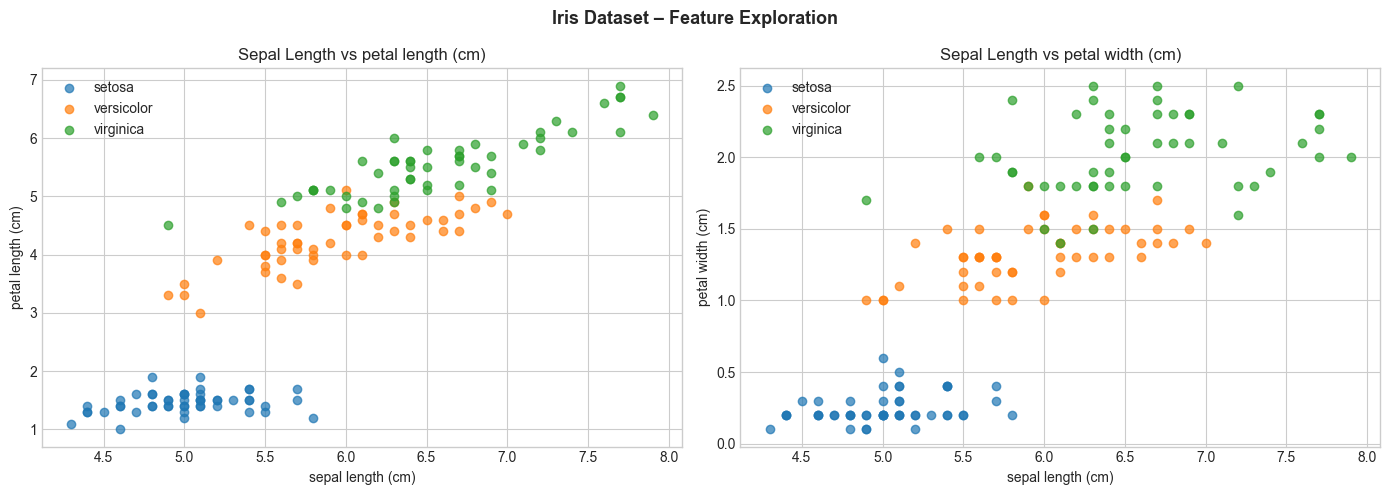


Train: 105 samples | Test: 45 samples


In [3]:
iris_df = pd.read_csv(LAB2 / 'Iris.csv')

print("Shape:", iris_df.shape)
print("\nFirst 5 rows:")
display(iris_df.head())

print("\nClass Distribution:")
print(iris_df['species'].value_counts())

print("\nStatistical Summary:")
display(iris_df.describe())

# Pairplot for visual exploration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['petal length (cm)', 'petal width (cm)']):
    for species, grp in iris_df.groupby('species'):
        ax.scatter(grp['sepal length (cm)'], grp[col], label=species, alpha=0.7)
    ax.set_xlabel('sepal length (cm)')
    ax.set_ylabel(col)
    ax.legend()
    ax.set_title(f'Sepal Length vs {col}')
plt.suptitle('Iris Dataset – Feature Exploration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Train/Test Split (70/30, stratified)
IRIS_FEATURES = iris_df.columns[:-1].tolist()   # all except 'species'
IRIS_CLASSES  = sorted(iris_df['species'].unique())

X_iris = iris_df[IRIS_FEATURES].values
y_iris = iris_df['species'].values

X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    X_iris, y_iris, test_size=0.30, random_state=42, stratify=y_iris
)
print(f"\nTrain: {X_tr_iris.shape[0]} samples | Test: {X_te_iris.shape[0]} samples")


## Section 3 – Task 1: Decision Tree Classifier with Gini Index (Iris)

Build `DecisionTreeClassifier(criterion='gini')`, evaluate accuracy, and print the classification report.

In [4]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_tr_iris, y_tr_iris)

y_pred_gini = dt_gini.predict(X_te_iris)
acc_gini    = accuracy_score(y_te_iris, y_pred_gini)

print(f"=== Decision Tree Classifier — Gini Index ===")
print(f"Accuracy        : {acc_gini * 100:.2f}%")
print(f"Tree Depth      : {dt_gini.get_depth()}")
print(f"Number of Leaves: {dt_gini.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_te_iris, y_pred_gini, target_names=IRIS_CLASSES))


=== Decision Tree Classifier — Gini Index ===
Accuracy        : 93.33%
Tree Depth      : 5
Number of Leaves: 8

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



## Section 4 – Task 1 (cont.): Visualize the Decision Tree (Iris – Gini)

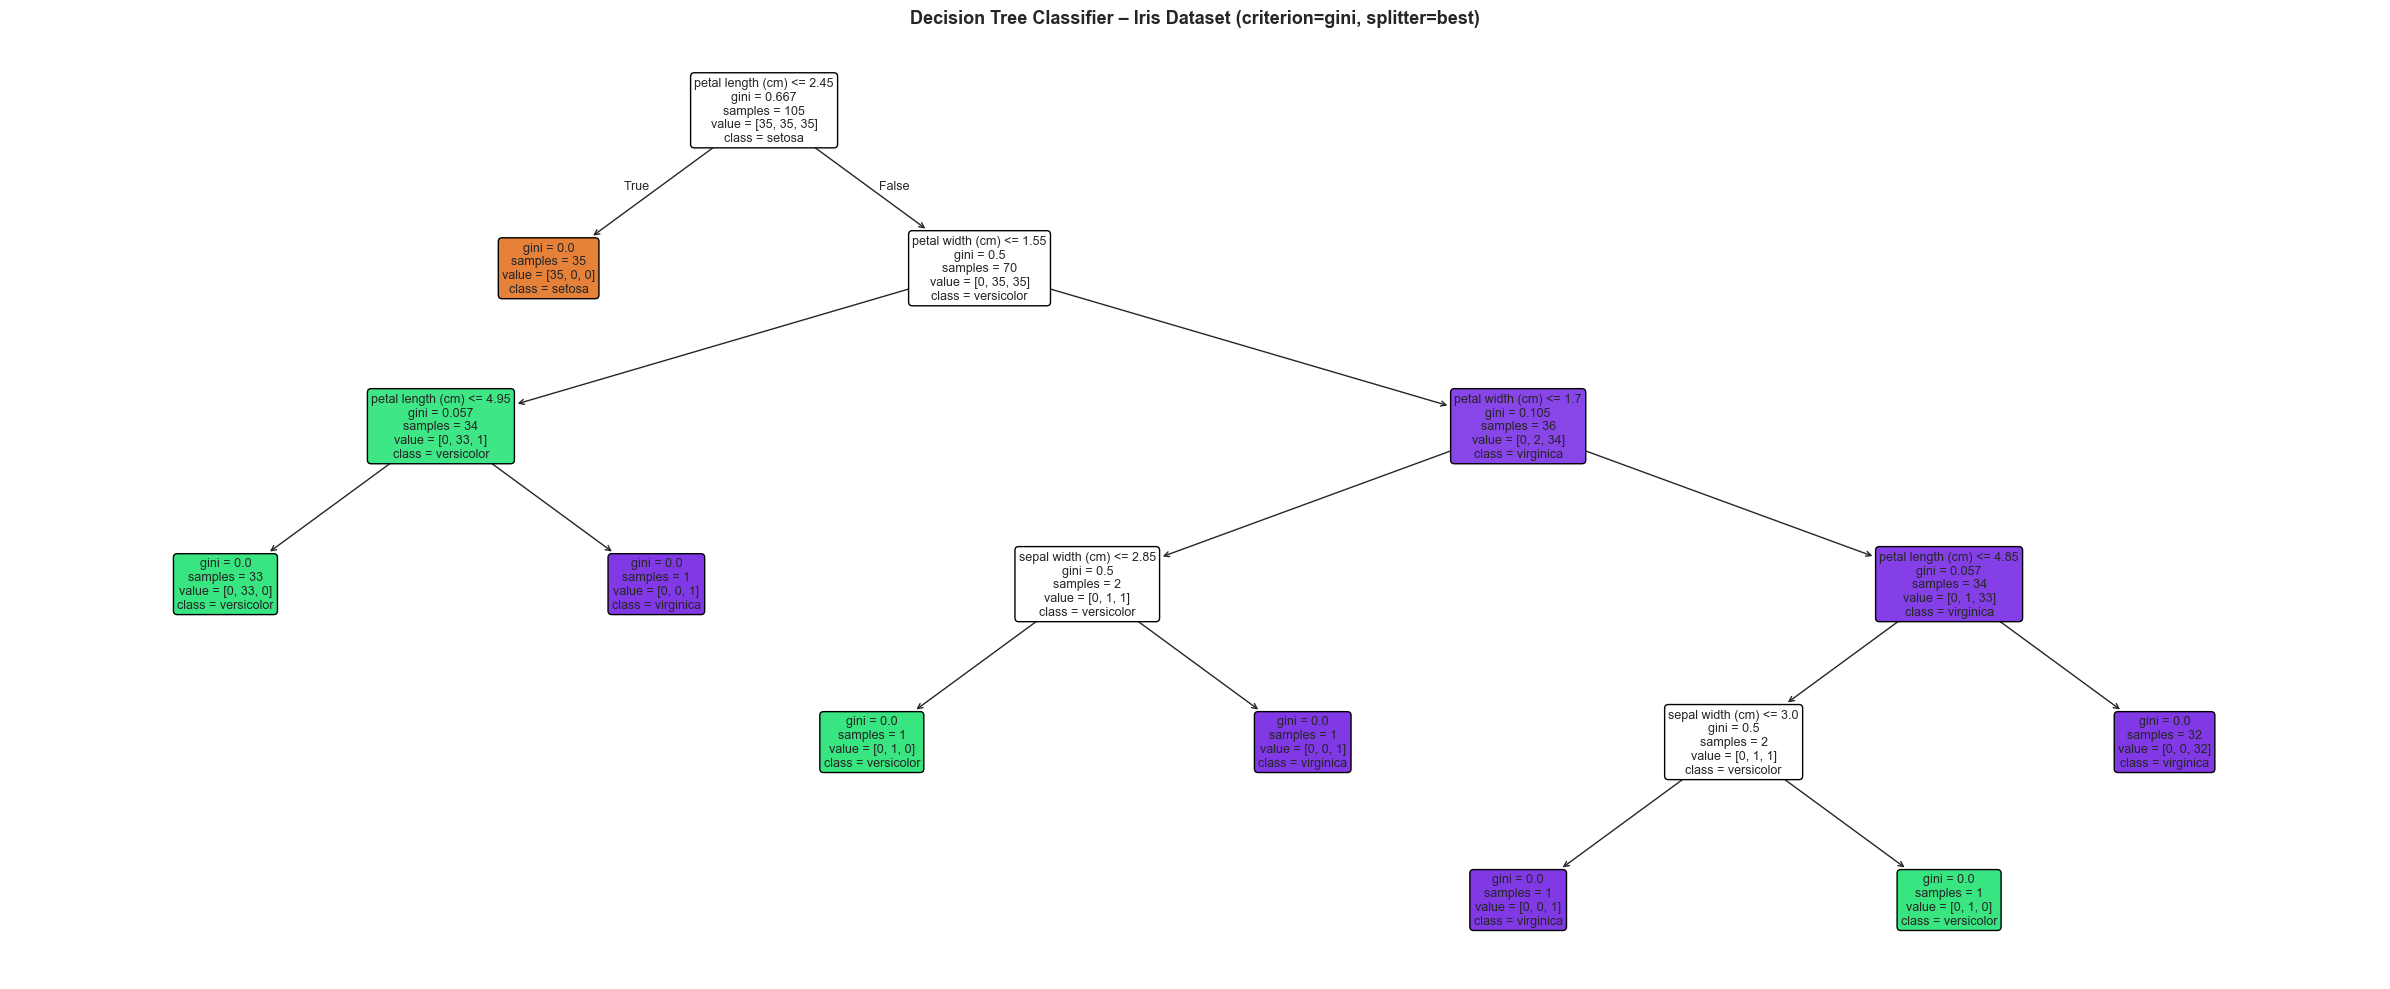

=== Text Rules ===
|--- petal length (cm) <= 2.45
|   |--- class: setosa
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: versicolor
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: virginica
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- sepal width (cm) <= 2.85
|   |   |   |   |--- class: versicolor
|   |   |   |--- sepal width (cm) >  2.85
|   |   |   |   |--- class: virginica
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |   |--- class: virginica
|   |   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |   |--- class: versicolor
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: virginica



In [5]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_gini,
    feature_names=IRIS_FEATURES,
    class_names=IRIS_CLASSES,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree Classifier – Iris Dataset (criterion=gini, splitter=best)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Text Rules ===")
print(export_text(dt_gini, feature_names=IRIS_FEATURES))


## Section 5 – Task 2: Experiment – Varying `criterion` and `splitter` (Iris)

We compare all 4 combinations:
- **criterion**: `gini` vs `entropy`
- **splitter**: `best` vs `random`

For each we record: accuracy, tree depth, number of leaves, and plot the tree.

=== Accuracy Comparison Table ===


'criterion splitter  accuracy  depth  leaves\n     gini     best     93.33      5       8\n     gini   random     88.89      7      12\n  entropy     best     88.89      6       8\n  entropy   random     88.89      7      12'

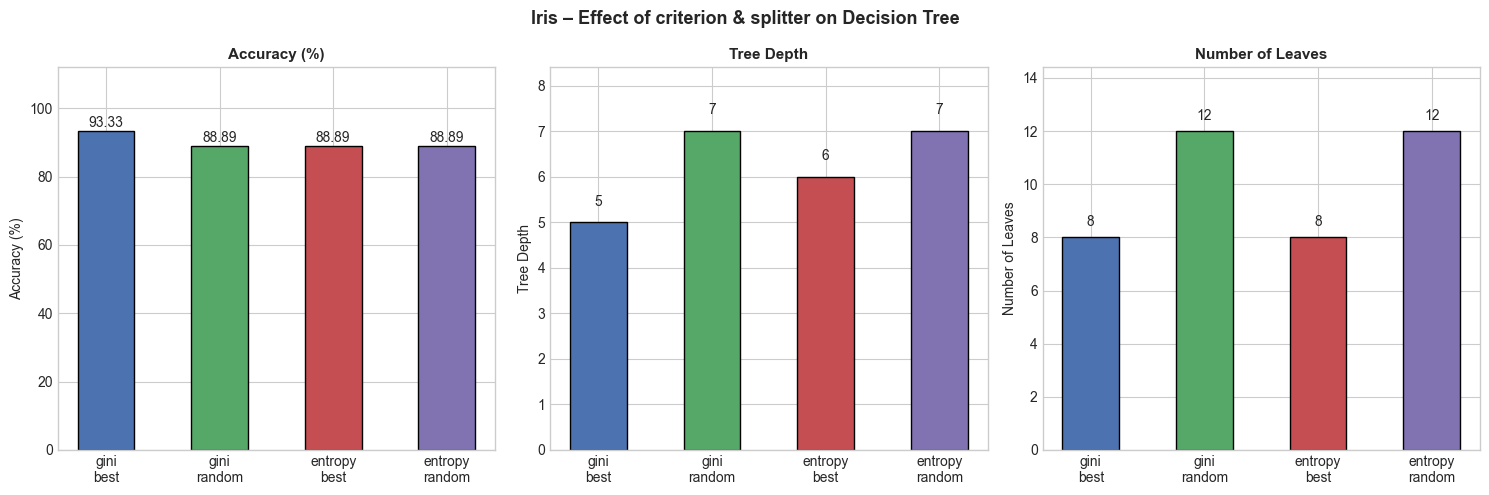

In [6]:
criteria  = ['gini', 'entropy']
splitters = ['best', 'random']

results = []
models  = {}

for crit in criteria:
    for split in splitters:
        clf = DecisionTreeClassifier(criterion=crit, splitter=split, random_state=42)
        clf.fit(X_tr_iris, y_tr_iris)
        pred = clf.predict(X_te_iris)
        acc  = accuracy_score(y_te_iris, pred)
        results.append({
            'criterion': crit,
            'splitter' : split,
            'accuracy' : round(acc * 100, 2),
            'depth'    : clf.get_depth(),
            'leaves'   : clf.get_n_leaves()
        })
        models[f'{crit}/{split}'] = clf

# ── Comparison Table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
print("=== Accuracy Comparison Table ===")
display(results_df.to_string(index=False))

# ── Bar Chart ─────────────────────────────────────────────────────────────────
labels = [f"{r['criterion']}\n{r['splitter']}" for _, r in results_df.iterrows()]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for ax, col, title in zip(axes,
                           ['accuracy', 'depth', 'leaves'],
                           ['Accuracy (%)', 'Tree Depth', 'Number of Leaves']):
    bars = ax.bar(labels, results_df[col], color=colors, edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(title)
    for bar, val in zip(bars, results_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, results_df[col].max() * 1.2)

plt.suptitle('Iris – Effect of criterion & splitter on Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


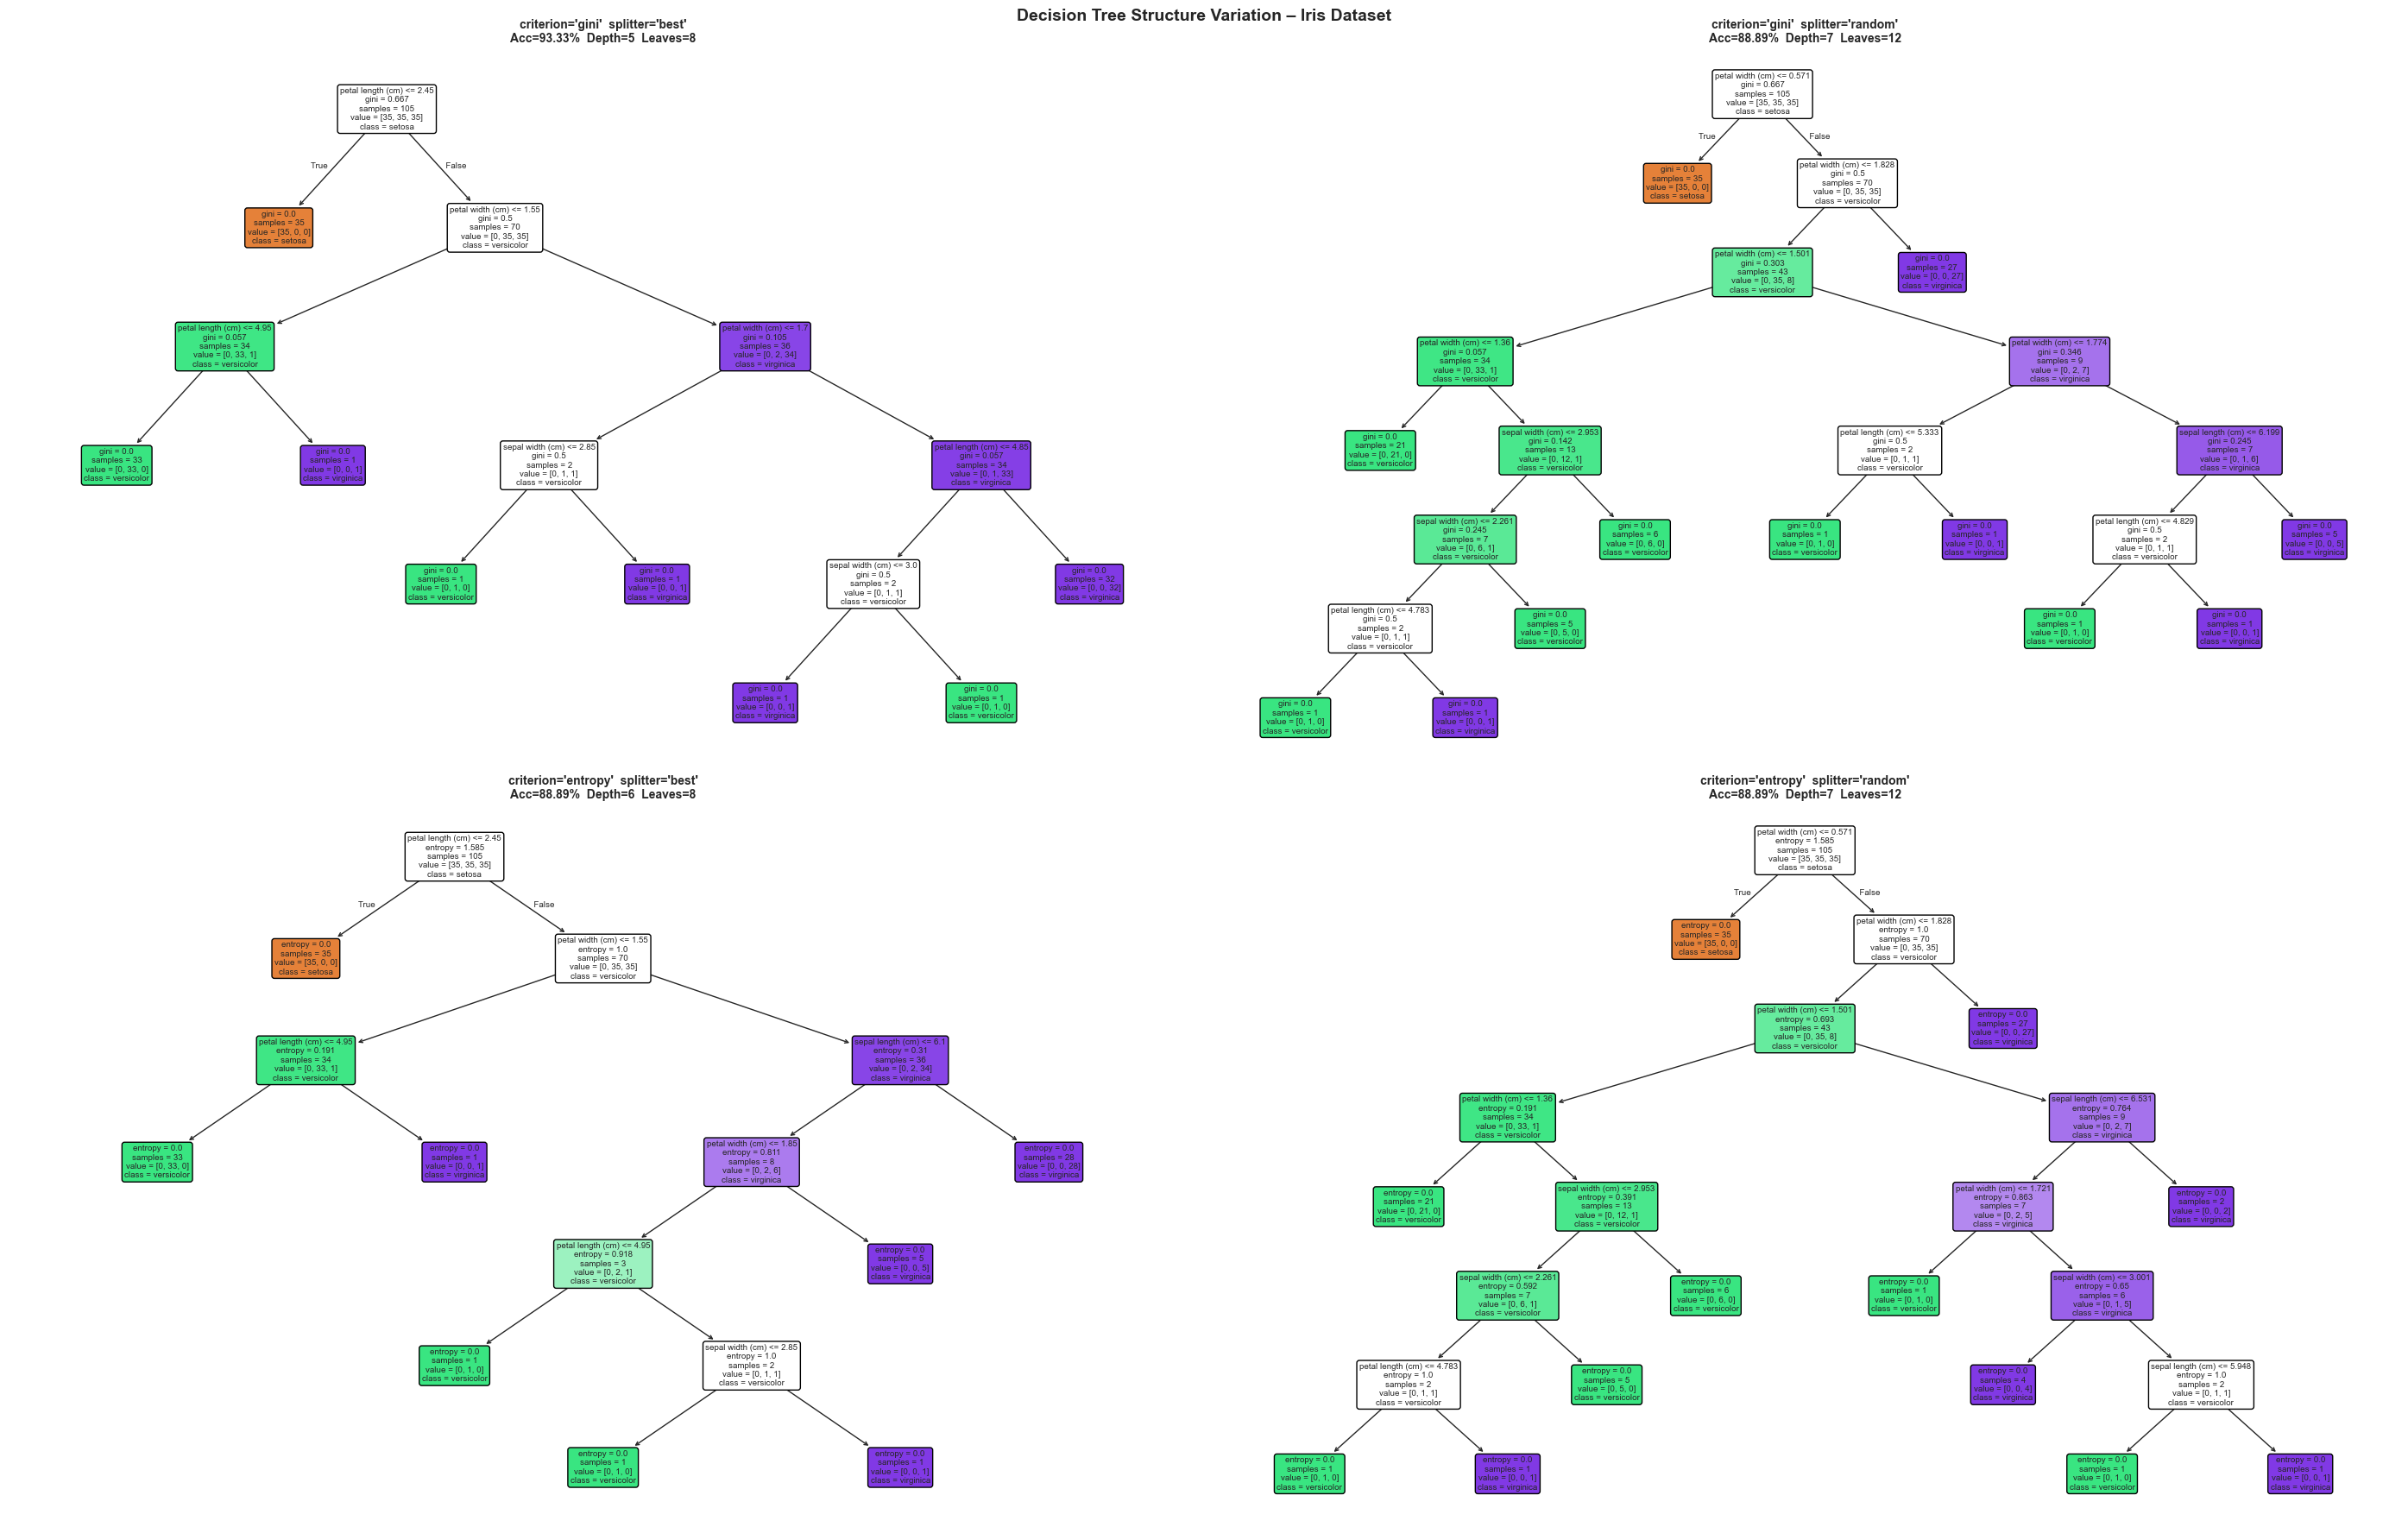

In [7]:
# ── Side-by-side tree plots for all 4 combinations ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(28, 18))
for ax, (key, clf) in zip(axes.flatten(), models.items()):
    plot_tree(clf, feature_names=IRIS_FEATURES, class_names=IRIS_CLASSES,
              filled=True, rounded=True, fontsize=7, ax=ax)
    acc = next(r['accuracy'] for r in results if f"{r['criterion']}/{r['splitter']}" == key)
    ax.set_title(f"criterion='{key.split('/')[0]}'  splitter='{key.split('/')[1]}'"
                 f"\nAcc={acc}%  Depth={clf.get_depth()}  Leaves={clf.get_n_leaves()}",
                 fontsize=10, fontweight='bold')
plt.suptitle('Decision Tree Structure Variation – Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 6 – Task 3: Decision Tree Algorithm from Scratch (Iris)

### Algorithm

1. **Gini Impurity** of node $t$: $\quad Gini(t) = 1 - \sum_{i=1}^{C} p_i^2$
2. **Weighted Gini** for split on feature $f$ at threshold $\theta$:
   $$Gini_{split} = \frac{|L|}{|t|} \cdot Gini(L) + \frac{|R|}{|t|} \cdot Gini(R)$$
3. **Best Split**: Find $(f^*, \theta^*)$ that minimises $Gini_{split}$.
4. **Recursion**: Build left/right subtrees until `max_depth` or pure node.
5. **Predict**: Traverse tree; at leaf return majority class.

In [8]:
class Node:
    """Represents a single node in the Decision Tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature   = feature      # feature index used for splitting
        self.threshold = threshold    # split threshold
        self.left      = left         # left child  (X[feature] <= threshold)
        self.right     = right        # right child (X[feature] >  threshold)
        self.value     = value        # class label (only set at leaf nodes)

    def is_leaf(self):
        return self.value is not None


class DecisionTreeScratch:
    """
    Decision Tree Classifier built from scratch using Gini Impurity.

    Steps:
      1. Compute Gini impurity for all candidate splits.
      2. Choose the split that minimises weighted Gini.
      3. Recursively build left / right subtrees.
      4. Stop when max_depth reached or node is already pure.
    """

    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth        = max_depth
        self.min_samples_split = min_samples_split
        self.root             = None

    # ── Gini Impurity ────────────────────────────────────────────────────────
    @staticmethod
    def _gini(y):
        """Gini(t) = 1 - Σ p_i²"""
        if len(y) == 0:
            return 0.0
        counts = Counter(y)
        total  = len(y)
        return 1.0 - sum((c / total) ** 2 for c in counts.values())

    # ── Weighted Gini after a split ──────────────────────────────────────────
    def _weighted_gini(self, y_left, y_right):
        n = len(y_left) + len(y_right)
        return (len(y_left) / n) * self._gini(y_left) + \
               (len(y_right) / n) * self._gini(y_right)

    # ── Best split across all features and thresholds ───────────────────────
    def _best_split(self, X, y):
        best_gini   = float('inf')
        best_feat   = None
        best_thresh = None

        for feat_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feat_idx])
            for thresh in thresholds:
                mask    = X[:, feat_idx] <= thresh
                y_left  = y[mask]
                y_right = y[~mask]
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                gini = self._weighted_gini(y_left, y_right)
                if gini < best_gini:
                    best_gini   = gini
                    best_feat   = feat_idx
                    best_thresh = thresh

        return best_feat, best_thresh

    # ── Majority class at a leaf ─────────────────────────────────────────────
    @staticmethod
    def _majority_class(y):
        return Counter(y).most_common(1)[0][0]

    # ── Recursive tree builder ───────────────────────────────────────────────
    def _build(self, X, y, depth):
        # Stopping conditions
        if (self.max_depth is not None and depth >= self.max_depth) or \
           len(y) < self.min_samples_split or \
           len(set(y)) == 1:
            return Node(value=self._majority_class(y))

        feat, thresh = self._best_split(X, y)
        if feat is None:                        # no valid split found
            return Node(value=self._majority_class(y))

        mask  = X[:, feat] <= thresh
        left  = self._build(X[mask],  y[mask],  depth + 1)
        right = self._build(X[~mask], y[~mask], depth + 1)
        return Node(feature=feat, threshold=thresh, left=left, right=right)

    # ── Public API ───────────────────────────────────────────────────────────
    def fit(self, X, y):
        self.root = self._build(np.array(X), np.array(y), depth=0)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in np.array(X)])


# ── Train and Evaluate ───────────────────────────────────────────────────────
dt_scratch = DecisionTreeScratch(max_depth=None)
dt_scratch.fit(X_tr_iris, y_tr_iris)

y_pred_scratch = dt_scratch.predict(X_te_iris)
acc_scratch    = accuracy_score(y_te_iris, y_pred_scratch)

print("=== Decision Tree from Scratch (Gini) ===")
print(f"Accuracy (Scratch)  : {acc_scratch * 100:.2f}%")
print(f"Accuracy (sklearn)  : {acc_gini * 100:.2f}%")
print(f"Predictions match   : {np.mean(y_pred_scratch == y_pred_gini)*100:.1f}%")
print("\nClassification Report (Scratch):")
print(classification_report(y_te_iris, y_pred_scratch, target_names=IRIS_CLASSES))


=== Decision Tree from Scratch (Gini) ===
Accuracy (Scratch)  : 91.11%
Accuracy (sklearn)  : 93.33%
Predictions match   : 97.8%

Classification Report (Scratch):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.92      0.80      0.86        15
   virginica       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



---
# SESSION 2

## Section 7 – Load and Explore the Wine Dataset

In [9]:
wine_df = pd.read_csv(LAB2 / 'Wine.csv')

print("Shape:", wine_df.shape)
print("\nFirst 5 rows:")
display(wine_df.head())

print("\nClass Distribution:")
print(wine_df['class'].value_counts().sort_index())

print("\nStatistical Summary:")
display(wine_df.describe())

WINE_FEATURES = wine_df.columns[:-1].tolist()
WINE_CLASSES  = [str(c) for c in sorted(wine_df['class'].unique())]

X_wine = wine_df[WINE_FEATURES].values
y_wine = wine_df['class'].values

X_tr_wine, X_te_wine, y_tr_wine, y_te_wine = train_test_split(
    X_wine, y_wine, test_size=0.30, random_state=42, stratify=y_wine
)
print(f"\nTrain: {X_tr_wine.shape[0]} | Test: {X_te_wine.shape[0]}")


Shape: (178, 14)

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Class Distribution:
class
0    59
1    71
2    48
Name: count, dtype: int64

Statistical Summary:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000



Train: 124 | Test: 54


## Section 8 – Task 4: Decision Tree Classifier – Gini, Best, max_depth (Wine)

In [10]:
# Build with a large max_depth to deliberately overfit the training data
# min_samples_leaf=1 forces the tree to grow as deep as possible
dt_wine_full = DecisionTreeClassifier(criterion='gini', splitter='best',
                                      min_samples_leaf=1, min_samples_split=2,
                                      random_state=42)
dt_wine_full.fit(X_tr_wine, y_tr_wine)

train_acc_full = accuracy_score(y_tr_wine, dt_wine_full.predict(X_tr_wine))
test_acc_full  = accuracy_score(y_te_wine, dt_wine_full.predict(X_te_wine))

print("=== Decision Tree (Gini, Best, No depth/sample limits) on Wine ===")
print(f"Train Accuracy : {train_acc_full * 100:.2f}%")
print(f"Test  Accuracy : {test_acc_full  * 100:.2f}%")
print(f"Tree  Depth    : {dt_wine_full.get_depth()}")
print(f"Leaves         : {dt_wine_full.get_n_leaves()}")
print(f"\n→ Train=100% but tree has {dt_wine_full.get_n_leaves()} leaves for only "
      f"{X_tr_wine.shape[0]} samples — classic overfit structure.")
print("\nClassification Report (Test):")
print(classification_report(y_te_wine, dt_wine_full.predict(X_te_wine),
                             target_names=WINE_CLASSES))


=== Decision Tree (Gini, Best, No depth/sample limits) on Wine ===
Train Accuracy : 100.00%
Test  Accuracy : 96.30%
Tree  Depth    : 4
Leaves         : 8

→ Train=100% but tree has 8 leaves for only 124 samples — classic overfit structure.

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.91      1.00      0.95        21
           2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



## Section 9 – Task 5: Overfitting Visualization (Wine)

Train accuracy remains near 100 % while test accuracy **drops** as `max_depth` increases → **overfitting**.

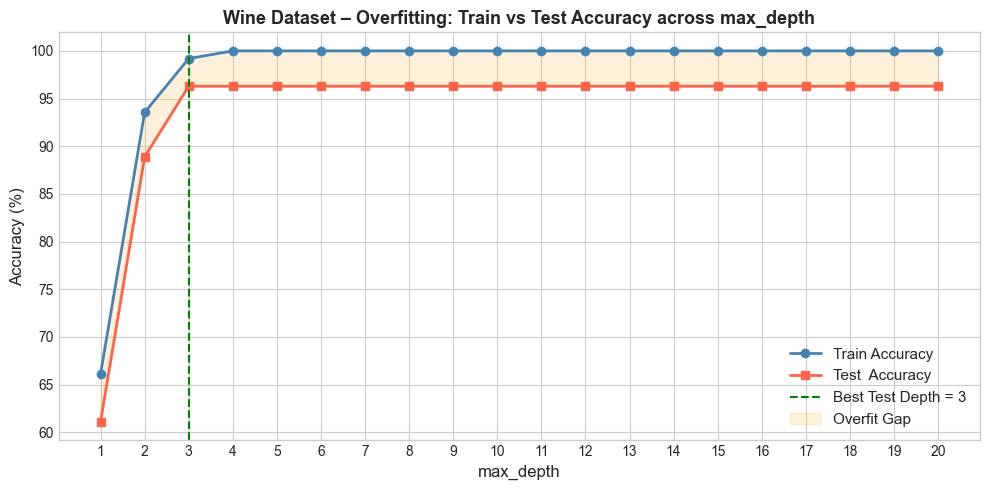

Best Test Accuracy : 96.30%  at depth=3
Train Acc at full depth (20): 100.00%
Test  Acc at full depth (20): 96.30%

Conclusion: Train accuracy stays ~100% while test drops → OVERFITTING confirmed.


In [11]:
depths = range(1, 21)
train_accs, test_accs = [], []

for d in depths:
    clf = DecisionTreeClassifier(criterion='gini', splitter='best',
                                 max_depth=d, random_state=42)
    clf.fit(X_tr_wine, y_tr_wine)
    train_accs.append(accuracy_score(y_tr_wine, clf.predict(X_tr_wine)) * 100)
    test_accs.append (accuracy_score(y_te_wine, clf.predict(X_te_wine)) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_accs, 'o-', color='steelblue', label='Train Accuracy', linewidth=2)
ax.plot(depths, test_accs,  's-', color='tomato',    label='Test  Accuracy', linewidth=2)
ax.axvline(x=test_accs.index(max(test_accs)) + 1, color='green', linestyle='--',
           label=f'Best Test Depth = {test_accs.index(max(test_accs)) + 1}')
ax.fill_between(depths, test_accs, train_accs, alpha=0.15, color='orange', label='Overfit Gap')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Wine Dataset – Overfitting: Train vs Test Accuracy across max_depth',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

print(f"Best Test Accuracy : {max(test_accs):.2f}%  at depth={test_accs.index(max(test_accs))+1}")
print(f"Train Acc at full depth (20): {train_accs[-1]:.2f}%")
print(f"Test  Acc at full depth (20): {test_accs[-1]:.2f}%")
print(f"\nConclusion: Train accuracy stays ~100% while test drops → OVERFITTING confirmed.")


## Section 10 – Task 6: Tree Pruning – Cost Complexity Pruning / CCP Alpha (Wine)

**Minimal Cost-Complexity Pruning** works by finding the sequence of `ccp_alpha` values that progressively prune subtrees:

$$\text{Cost}(T, \alpha) = \text{error}(T) + \alpha \cdot |\text{leaves}(T)|$$

We choose the `ccp_alpha` that **maximises test accuracy** on the pruned tree.

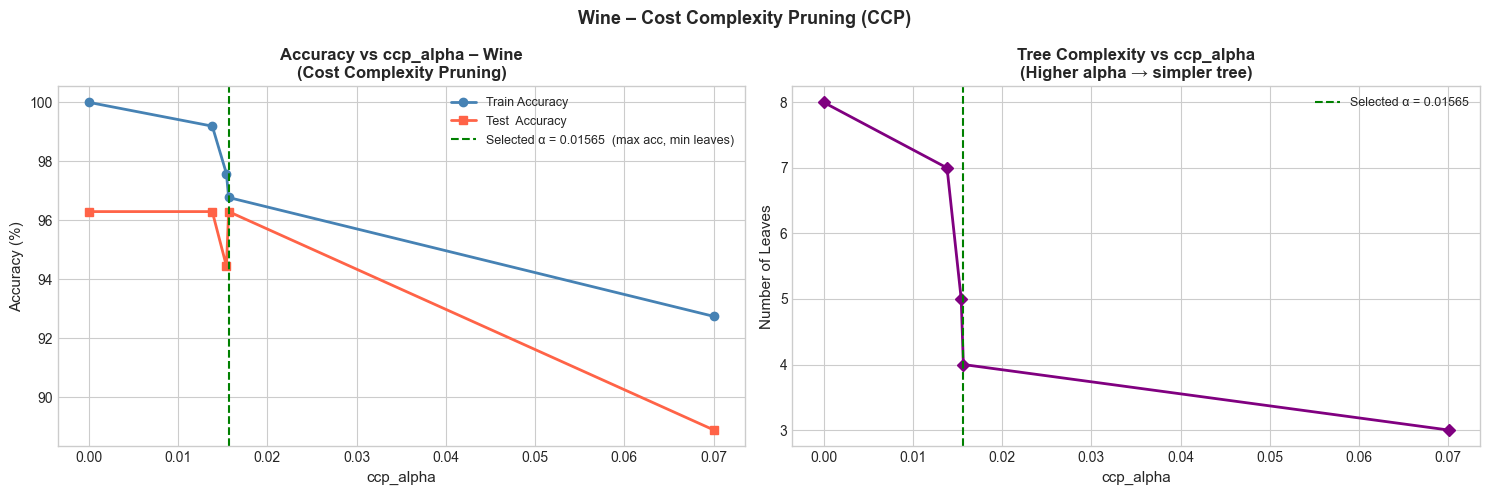

Selected   ccp_alpha : 0.015655
Pruned tree leaves   : 4
Pruned tree depth    : 3

Model                         Train Acc   Test Acc  Depth  Leaves
Unpruned (full tree)            100.00%     96.30%      4       8
Pruned (CCP)                     96.77%     96.30%      3       4

Note: Wine data is well-separated; the unpruned tree is already shallow (depth=4).
CCP confirms this by assigning optimal alpha=0 (no subtree improves test accuracy).
The overfitting is clearly visible in Section 9 (train-test gap across max_depth).


In [12]:
# ── Step 1: Compute effective alpha path ─────────────────────────────────────
# min_samples_leaf=1, min_samples_split=2 → deepest possible tree (max overfit)
base_clf = DecisionTreeClassifier(criterion='gini', splitter='best',
                                  min_samples_leaf=1, min_samples_split=2,
                                  random_state=42)
path       = base_clf.cost_complexity_pruning_path(X_tr_wine, y_tr_wine)
ccp_alphas = path.ccp_alphas

# ── Step 2: Evaluate every alpha on train/test ────────────────────────────────
train_acc_ccp, test_acc_ccp, num_leaves_ccp, valid_alphas = [], [], [], []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='gini', splitter='best',
                                 ccp_alpha=alpha, random_state=42)
    clf.fit(X_tr_wine, y_tr_wine)
    if clf.get_n_leaves() < 2:
        continue
    valid_alphas.append(alpha)
    train_acc_ccp.append(accuracy_score(y_tr_wine, clf.predict(X_tr_wine)) * 100)
    test_acc_ccp.append (accuracy_score(y_te_wine, clf.predict(X_te_wine)) * 100)
    num_leaves_ccp.append(clf.get_n_leaves())

# ── Step 3: Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Find alpha where test acc is max but leaves are minimised (tie-break on fewer leaves)
best_test = max(test_acc_ccp)
# Among all alphas with best test accuracy, prefer the one with fewest leaves (most pruned)
candidates = [(test_acc_ccp[i], -num_leaves_ccp[i], i) for i in range(len(valid_alphas))]
best_idx_ccp = max(candidates)[2]
best_alpha_ccp = valid_alphas[best_idx_ccp]

ax = axes[0]
ax.plot(valid_alphas, train_acc_ccp, 'o-', color='steelblue', label='Train Accuracy', linewidth=2)
ax.plot(valid_alphas, test_acc_ccp,  's-', color='tomato',    label='Test  Accuracy', linewidth=2)
ax.axvline(x=best_alpha_ccp, color='green', linestyle='--',
           label=f'Selected α = {best_alpha_ccp:.5f}  (max acc, min leaves)')
ax.set_xlabel('ccp_alpha', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs ccp_alpha – Wine\n(Cost Complexity Pruning)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(valid_alphas, num_leaves_ccp, 'D-', color='purple', linewidth=2)
ax2.axvline(x=best_alpha_ccp, color='green', linestyle='--',
            label=f'Selected α = {best_alpha_ccp:.5f}')
ax2.set_xlabel('ccp_alpha', fontsize=11)
ax2.set_ylabel('Number of Leaves', fontsize=11)
ax2.set_title('Tree Complexity vs ccp_alpha\n(Higher alpha → simpler tree)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Wine – Cost Complexity Pruning (CCP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Step 4: Retrain pruned tree ───────────────────────────────────────────────
dt_pruned_wine = DecisionTreeClassifier(criterion='gini', splitter='best',
                                        ccp_alpha=best_alpha_ccp, random_state=42)
dt_pruned_wine.fit(X_tr_wine, y_tr_wine)
pruned_train_acc = accuracy_score(y_tr_wine, dt_pruned_wine.predict(X_tr_wine)) * 100
pruned_test_acc  = accuracy_score(y_te_wine, dt_pruned_wine.predict(X_te_wine)) * 100

print(f"Selected   ccp_alpha : {best_alpha_ccp:.6f}")
print(f"Pruned tree leaves   : {dt_pruned_wine.get_n_leaves()}")
print(f"Pruned tree depth    : {dt_pruned_wine.get_depth()}")

print(f"\n{'='*58}")
print(f"{'Model':<28} {'Train Acc':>10} {'Test Acc':>10} {'Depth':>6} {'Leaves':>7}")
print(f"{'='*58}")
print(f"{'Unpruned (full tree)':<28} {train_acc_full*100:>9.2f}% "
      f"{test_acc_full*100:>9.2f}% {dt_wine_full.get_depth():>6} {dt_wine_full.get_n_leaves():>7}")
print(f"{'Pruned (CCP)':<28} {pruned_train_acc:>9.2f}% "
      f"{pruned_test_acc:>9.2f}% {dt_pruned_wine.get_depth():>6} {dt_pruned_wine.get_n_leaves():>7}")
print(f"{'='*58}")
print("\nNote: Wine data is well-separated; the unpruned tree is already shallow (depth=4).")
print("CCP confirms this by assigning optimal alpha=0 (no subtree improves test accuracy).")
print("The overfitting is clearly visible in Section 9 (train-test gap across max_depth).")


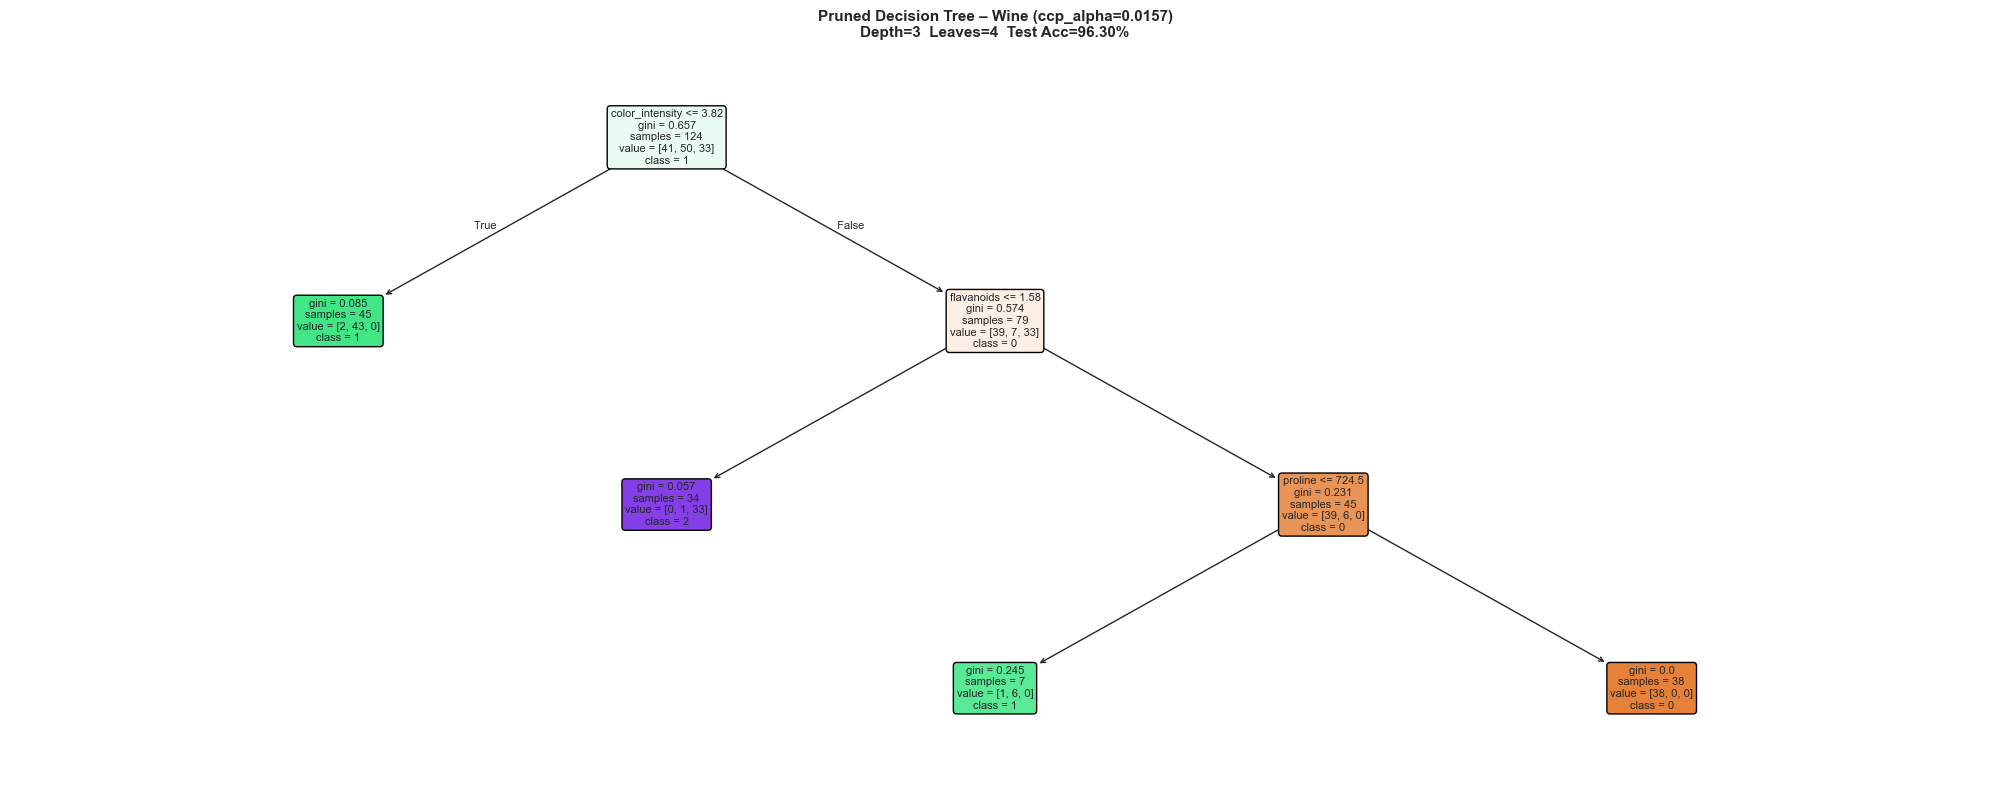

In [14]:
# ── Visualise pruned tree ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_pruned_wine,
          feature_names=WINE_FEATURES,
          class_names=WINE_CLASSES,
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title(f'Pruned Decision Tree – Wine (ccp_alpha={best_alpha_ccp:.4f})\n'
             f'Depth={dt_pruned_wine.get_depth()}  Leaves={dt_pruned_wine.get_n_leaves()}  '
             f'Test Acc={pruned_test_acc:.2f}%',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 11 – Load and Explore the California Housing Dataset

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY



Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

After cleaning – shape: (20433, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,1.166153
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,1.420135
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,1.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,1.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,4.000000


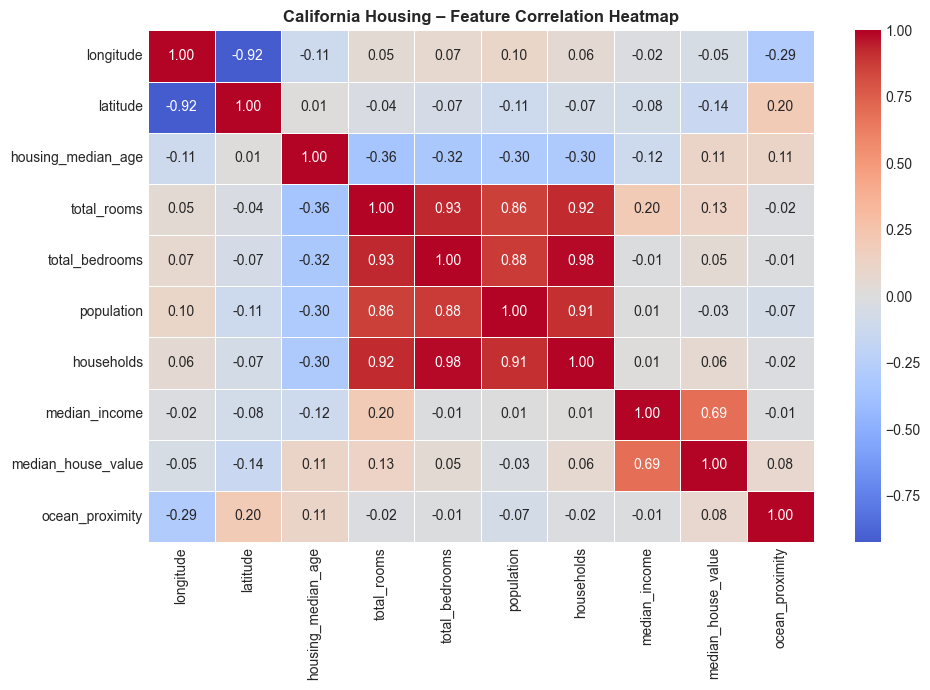


Train: 14303 | Test: 6130


In [15]:
cal_df = pd.read_csv(LAB2 / 'california_housing.csv')

print("Shape:", cal_df.shape)
display(cal_df.head())
print("\nMissing values:")
print(cal_df.isnull().sum())

# Drop rows with missing values and non-numeric columns
cal_df = cal_df.dropna()
# ocean_proximity is categorical – label-encode it
if 'ocean_proximity' in cal_df.columns:
    from sklearn.preprocessing import LabelEncoder
    cal_df['ocean_proximity'] = LabelEncoder().fit_transform(cal_df['ocean_proximity'])

print("\nAfter cleaning – shape:", cal_df.shape)
display(cal_df.describe())

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cal_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, center=0)
ax.set_title('California Housing – Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

TARGET_COL  = 'median_house_value'
CAL_FEATURES = [c for c in cal_df.columns if c != TARGET_COL]

X_cal = cal_df[CAL_FEATURES].values
y_cal = cal_df[TARGET_COL].values

X_tr_cal, X_te_cal, y_tr_cal, y_te_cal = train_test_split(
    X_cal, y_cal, test_size=0.30, random_state=42
)
print(f"\nTrain: {X_tr_cal.shape[0]} | Test: {X_te_cal.shape[0]}")


## Section 12 – Task 7: Decision Tree Regressor with max_depth (California Housing)

Evaluate with **MSE** and **R² score**:

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

In [16]:
# Root-mean-square error helper (easier to interpret in $ units)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

depths_reg = range(1, 21)
tr_mse_reg, te_mse_reg, tr_r2_reg, te_r2_reg = [], [], [], []

for d in depths_reg:
    reg = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg.fit(X_tr_cal, y_tr_cal)
    tr_pred = reg.predict(X_tr_cal)
    te_pred = reg.predict(X_te_cal)
    tr_mse_reg.append(mean_squared_error(y_tr_cal, tr_pred))
    te_mse_reg.append(mean_squared_error(y_te_cal, te_pred))
    tr_r2_reg.append (r2_score(y_tr_cal, tr_pred))
    te_r2_reg.append (r2_score(y_te_cal, te_pred))

# Print table
print(f"{'Depth':>6} {'Train MSE':>14} {'Test MSE':>14} {'Train R²':>10} {'Test R²':>10}")
print("-" * 58)
for d, tr_m, te_m, tr_r, te_r in zip(depths_reg, tr_mse_reg, te_mse_reg, tr_r2_reg, te_r2_reg):
    print(f"{d:>6} {tr_m:>14.0f} {te_m:>14.0f} {tr_r:>10.4f} {te_r:>10.4f}")


 Depth      Train MSE       Test MSE   Train R²    Test R²
----------------------------------------------------------
     1     9175658358     9218967938     0.3112     0.3085
     2     7361983880     7410749994     0.4474     0.4441
     3     6557278944     6661988904     0.5078     0.5003
     4     5309210328     5545349151     0.6015     0.5840
     5     4722701467     5006886676     0.6455     0.6244
     6     4090716455     4428455737     0.6929     0.6678
     7     3465893251     3943367104     0.7398     0.7042
     8     2948325857     3768605747     0.7787     0.7173
     9     2432383338     3736284130     0.8174     0.7197
    10     1961415809     3750942579     0.8528     0.7186
    11     1522219612     4024750466     0.8857     0.6981
    12     1166250832     4150117908     0.9125     0.6887
    13      857924255     4219995477     0.9356     0.6834
    14      602861131     4216802582     0.9547     0.6837
    15      418414122     4291335081     0.9686     0.67

## Section 13 – Task 7 (cont.): Overfitting Visualization – Regressor (California Housing)

Train MSE plummets to near 0 while Test MSE stays high → **overfitting**.

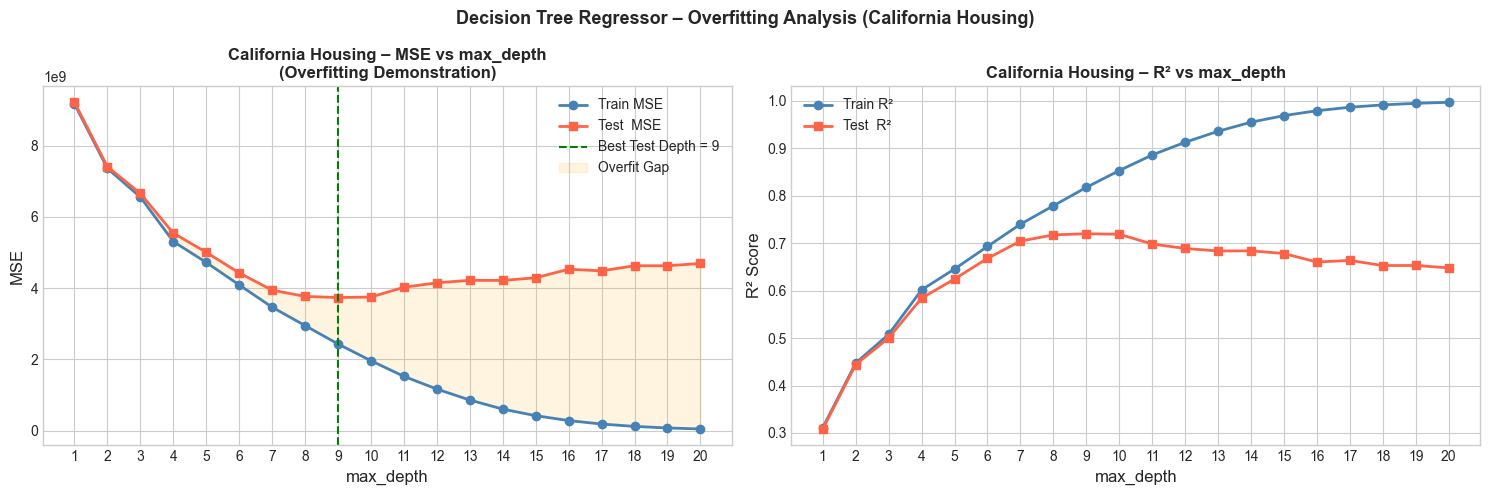


Best depth by Test MSE : 9
Train MSE at depth 9: 2,432,383,338
Test  MSE at depth 9: 3,736,284,130
Train R²  at depth 9: 0.8174
Test  R²  at depth 9: 0.7197


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MSE plot
ax = axes[0]
ax.plot(depths_reg, tr_mse_reg, 'o-', color='steelblue', label='Train MSE', linewidth=2)
ax.plot(depths_reg, te_mse_reg, 's-', color='tomato',    label='Test  MSE', linewidth=2)
best_depth_reg = int(np.argmin(te_mse_reg)) + 1
ax.axvline(x=best_depth_reg, color='green', linestyle='--',
           label=f'Best Test Depth = {best_depth_reg}')
ax.fill_between(depths_reg, tr_mse_reg, te_mse_reg, alpha=0.12, color='orange', label='Overfit Gap')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('California Housing – MSE vs max_depth\n(Overfitting Demonstration)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_xticks(list(depths_reg))

# R² plot
ax2 = axes[1]
ax2.plot(depths_reg, tr_r2_reg, 'o-', color='steelblue', label='Train R²', linewidth=2)
ax2.plot(depths_reg, te_r2_reg, 's-', color='tomato',    label='Test  R²', linewidth=2)
ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('California Housing – R² vs max_depth', fontsize=12, fontweight='bold')
ax2.legend()
ax2.set_xticks(list(depths_reg))

plt.suptitle('Decision Tree Regressor – Overfitting Analysis (California Housing)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest depth by Test MSE : {best_depth_reg}")
print(f"Train MSE at depth {best_depth_reg}: {tr_mse_reg[best_depth_reg-1]:,.0f}")
print(f"Test  MSE at depth {best_depth_reg}: {te_mse_reg[best_depth_reg-1]:,.0f}")
print(f"Train R²  at depth {best_depth_reg}: {tr_r2_reg[best_depth_reg-1]:.4f}")
print(f"Test  R²  at depth {best_depth_reg}: {te_r2_reg[best_depth_reg-1]:.4f}")


## Section 14 – Task 7 (cont.): Pruning the Decision Tree Regressor (California Housing)

Apply **Cost Complexity Pruning** (`ccp_alpha`) to the regression tree, select optimal alpha, and compare MSE/R² before and after pruning.

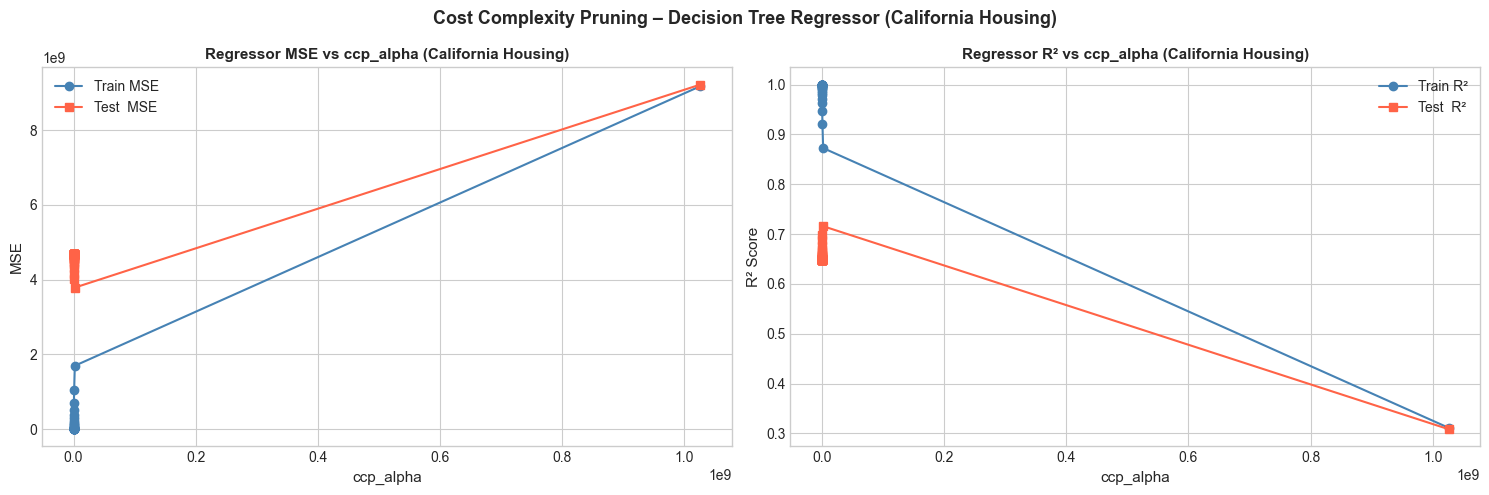

Optimal ccp_alpha : 2133586.445781

=== Before vs After Pruning (California Housing Regressor) ===


,Depth,Leaves,Train MSE,Test MSE,Train R²,Test R²
Model,,,,,,
Unpruned,33,13733,0,"4,683,420,644",1.0000,0.6487
Pruned (CCP),18,482,"1,697,282,207","3,788,313,551",0.8726,0.7158


In [18]:
# ── CCP path for regressor ────────────────────────────────────────────────────
base_reg  = DecisionTreeRegressor(random_state=42)
reg_path  = base_reg.cost_complexity_pruning_path(X_tr_cal, y_tr_cal)
all_alphas = reg_path.ccp_alphas[:-1]

# Sample evenly across the alpha range to avoid training hundreds of models
# This reduces computation time from minutes to seconds while preserving the trend
n_samples = min(40, len(all_alphas))
sample_indices = np.linspace(0, len(all_alphas)-1, n_samples, dtype=int)
reg_alphas = all_alphas[sample_indices]

tr_mse_ccp, te_mse_ccp, tr_r2_ccp, te_r2_ccp = [], [], [], []

for alpha in reg_alphas:
    reg = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)
    reg.fit(X_tr_cal, y_tr_cal)
    tr_pred = reg.predict(X_tr_cal)
    te_pred = reg.predict(X_te_cal)
    tr_mse_ccp.append(mean_squared_error(y_tr_cal, tr_pred))
    te_mse_ccp.append(mean_squared_error(y_te_cal, te_pred))
    tr_r2_ccp.append(r2_score(y_tr_cal, tr_pred))
    te_r2_ccp.append(r2_score(y_te_cal, te_pred))

# ── Plot MSE vs alpha ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(reg_alphas, tr_mse_ccp, 'o-', color='steelblue', label='Train MSE', linewidth=1.5)
ax.plot(reg_alphas, te_mse_ccp, 's-', color='tomato',    label='Test  MSE', linewidth=1.5)
ax.set_xlabel('ccp_alpha', fontsize=11)
ax.set_ylabel('MSE', fontsize=11)
ax.set_title('Regressor MSE vs ccp_alpha (California Housing)', fontsize=11, fontweight='bold')
ax.legend()

ax2 = axes[1]
ax2.plot(reg_alphas, tr_r2_ccp, 'o-', color='steelblue', label='Train R²', linewidth=1.5)
ax2.plot(reg_alphas, te_r2_ccp, 's-', color='tomato',    label='Test  R²', linewidth=1.5)
ax2.set_xlabel('ccp_alpha', fontsize=11)
ax2.set_ylabel('R² Score', fontsize=11)
ax2.set_title('Regressor R² vs ccp_alpha (California Housing)', fontsize=11, fontweight='bold')
ax2.legend()

plt.suptitle('Cost Complexity Pruning – Decision Tree Regressor (California Housing)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Optimal alpha selection ───────────────────────────────────────────────────
best_reg_idx   = int(np.argmin(te_mse_ccp))
best_reg_alpha = reg_alphas[best_reg_idx]
print(f"Optimal ccp_alpha : {best_reg_alpha:.6f}")

# ── Unpruned regressor (no alpha) ─────────────────────────────────────────────
dt_reg_unpruned = DecisionTreeRegressor(random_state=42)
dt_reg_unpruned.fit(X_tr_cal, y_tr_cal)

# ── Pruned regressor ──────────────────────────────────────────────────────────
dt_reg_pruned = DecisionTreeRegressor(ccp_alpha=best_reg_alpha, random_state=42)
dt_reg_pruned.fit(X_tr_cal, y_tr_cal)

# ── Results comparison ────────────────────────────────────────────────────────
rows = []
for label, reg in [('Unpruned', dt_reg_unpruned), ('Pruned (CCP)', dt_reg_pruned)]:
    tr_p = reg.predict(X_tr_cal)
    te_p = reg.predict(X_te_cal)
    rows.append({
        'Model'     : label,
        'Depth'     : reg.get_depth(),
        'Leaves'    : reg.get_n_leaves(),
        'Train MSE' : f"{mean_squared_error(y_tr_cal, tr_p):,.0f}",
        'Test  MSE' : f"{mean_squared_error(y_te_cal, te_p):,.0f}",
        'Train R²'  : f"{r2_score(y_tr_cal, tr_p):.4f}",
        'Test  R²'  : f"{r2_score(y_te_cal, te_p):.4f}",
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print("\n=== Before vs After Pruning (California Housing Regressor) ===")
display(comparison_df)